In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import trange
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('seaborn-whitegrid')
import numpy as np

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


### Load MNIST dataset

In [3]:
# Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
train_loader = DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
test_loader = DataLoader(testset, batch_size=64, shuffle=False)

### Build Model

In [4]:
def train_model(model, train_loader, test_loader, loss_fn, optimizer, epochs, device):
    train_errors = []
    test_errors = []
    train_accuracies = []
    test_accuracies = []

    tqdm_epoch = trange(epochs)
    for epoch in tqdm_epoch:
        model.train()
        train_loss = 0.0
        correct_train = 0

        # Training
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            # Forward pass
            outputs = model(batch_X)
            loss = loss_fn(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct_train += (predicted == batch_y).sum().item()

        train_loss /= len(train_loader.dataset)
        train_accuracy = 100 * correct_train / len(train_loader.dataset)
        train_errors.append(train_loss)
        train_accuracies.append(train_accuracy)
        
        # Evaluation on test set
        model.eval()
        test_loss = 0.0
        correct_test = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                test_loss += loss.item() * batch_X.size(0)
                # Calculate accuracy
                _, predicted = torch.max(outputs.data, 1)
                correct_test += (predicted == batch_y).sum().item()

        test_loss /= len(test_loader.dataset)
        test_accuracy = 100 * correct_test / len(test_loader.dataset)
        test_errors.append(test_loss)
        test_accuracies.append(test_accuracy)

        tqdm_epoch.set_description(f"Epoch {epoch+1}/{epochs} \
            - Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, \
            Train Acc: {train_accuracy:.2f}%, Test Acc: {test_accuracy:.2f}%")

    history = dict()
    history['train_loss'] = train_errors
    history['test_loss'] = test_errors
    history['train_acc'] = train_accuracies
    history['test_acc'] = test_accuracies
        
    return history

In [5]:
no_epochs = 20

In [6]:
loss_fn = nn.CrossEntropyLoss()

In [7]:
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super(FashionMNISTCNN, self).__init__()
        
        # Define the layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Apply layers and activations
        x = torch.relu(self.conv1(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv2(x))
        x = nn.MaxPool2d(2, 2)(x)
        x = torch.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def initialize_weights(self, init_type):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                if init_type == 'normal':
                    init.normal_(m.weight, mean=0.0, std=0.01)
                elif init_type == 'uniform':
                    init.uniform_(m.weight, a=-0.03, b=0.03)
                elif init_type == 'lecun_normal':
                    init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='linear')
                elif init_type == 'lecun_uniform':
                    init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='linear')
                elif init_type == 'truncated_normal':
                    init.trunc_normal_(m.weight, mean=0.0, std=0.01)
                elif init_type == 'glorot_normal':
                    init.xavier_normal_(m.weight)
                elif init_type == 'glorot_uniform':
                    init.xavier_uniform_(m.weight)
                elif init_type == 'he_normal':
                    init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                elif init_type == 'he_uniform':
                    init.kaiming_uniform_(m.weight, mode='fan_out', nonlinearity='relu')
                elif init_type == 'orthogonal':
                    init.orthogonal_(m.weight)

                if m.bias is not None:
                    init.constant_(m.bias, 0)

### Normal fixed variance

In [8]:
normal_model = FashionMNISTCNN().to(device)
normal_model.initialize_weights("normal")

In [9]:
normal_optimizer = optim.Adam(normal_model.parameters(), lr=0.001)

In [10]:
normal_dict = train_model(normal_model, train_loader, test_loader,
                          loss_fn, normal_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Uniform fixed variance

In [11]:
uniform_model = FashionMNISTCNN().to(device)
uniform_model.initialize_weights("uniform")

In [12]:
uniform_optimizer = optim.Adam(uniform_model.parameters(), lr=0.001)

In [13]:
uniform_dict = train_model(uniform_model, train_loader, test_loader,
                          loss_fn, uniform_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### LeCun Normal

In [14]:
lecunnorm_model = FashionMNISTCNN().to(device)
lecunnorm_model.initialize_weights("lecun_normal")
lecunnorm_optimizer = optim.Adam(lecunnorm_model.parameters(), lr=0.001)

lecunnorm_dict = train_model(lecunnorm_model, train_loader, test_loader,
                          loss_fn, lecunnorm_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### LeCun Uniform

In [15]:
lecununif_model = FashionMNISTCNN().to(device)
lecununif_model.initialize_weights("lecun_uniform")
lecununif_optimizer = optim.Adam(lecununif_model.parameters(), lr=0.001)

lecununif_dict = train_model(lecununif_model, train_loader, test_loader,
                          loss_fn, lecununif_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Truncated Normal

In [17]:
truncnorm_model = FashionMNISTCNN().to(device)
truncnorm_model.initialize_weights("truncated_normal")
truncnorm_optimizer = optim.Adam(truncnorm_model.parameters(), lr=0.001)

truncnorm_dict = train_model(truncnorm_model, train_loader, test_loader,
                             loss_fn, truncnorm_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Glorot Normal

In [18]:
glorotnorm_model = FashionMNISTCNN().to(device)
glorotnorm_model.initialize_weights("glorot_normal")
glorotnorm_optimizer = optim.Adam(glorotnorm_model.parameters(), lr=0.001)

glorotnorm_dict = train_model(glorotnorm_model, train_loader, test_loader,
                             loss_fn, glorotnorm_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Glorot Uniform

In [19]:
glorotunif_model = FashionMNISTCNN().to(device)
glorotunif_model.initialize_weights("glorot_uniform")
glorotunif_optimizer = optim.Adam(glorotunif_model.parameters(), lr=0.001)

glorotunif_dict = train_model(glorotunif_model, train_loader, test_loader,
                             loss_fn, glorotunif_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### He Normal

In [21]:
henorm_model = FashionMNISTCNN().to(device)
henorm_model.initialize_weights("he_normal")
henorm_optimizer = optim.Adam(henorm_model.parameters(), lr=0.001)

henorm_dict = train_model(henorm_model, train_loader, test_loader,
                             loss_fn, henorm_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### He Uniform

In [22]:
heunif_model = FashionMNISTCNN().to(device)
heunif_model.initialize_weights("he_uniform")
heunif_optimizer = optim.Adam(heunif_model.parameters(), lr=0.001)

heunif_dict = train_model(heunif_model, train_loader, test_loader,
                             loss_fn, heunif_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Orthogonal

In [23]:
orthog_model = FashionMNISTCNN().to(device)
orthog_model.initialize_weights("orthogonal")
orthog_optimizer = optim.Adam(orthog_model.parameters(), lr=0.001)

orthog_dict = train_model(orthog_model, train_loader, test_loader,
                             loss_fn, orthog_optimizer, no_epochs, device)

  0%|          | 0/20 [00:00<?, ?it/s]

### Plot Training Loss

In [24]:
epochs = range(1, no_epochs + 1)

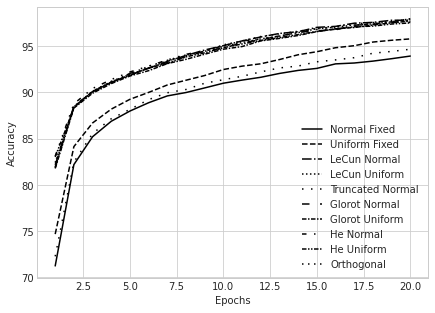

In [26]:
plt.figure(figsize=(7,5)) 
    
loss_values_gfixed = normal_dict['train_acc']
loss_values_ufixed = uniform_dict['train_acc']
loss_values_lecunnorm = lecunnorm_dict['train_acc']
loss_values_lecununiform = lecununif_dict['train_acc']
loss_values_trunc_norm = truncnorm_dict['train_acc']
loss_values_glorotnormal = glorotnorm_dict['train_acc']
loss_values_glorotunform = glorotunif_dict['train_acc']
loss_values_henormal = henorm_dict['train_acc']
loss_values_heuniform = heunif_dict['train_acc']
loss_values_orthog = orthog_dict['train_acc']
    
plt.plot(epochs, loss_values_gfixed, color='k', linestyle='-', label = 'Normal Fixed')
plt.plot(epochs, loss_values_ufixed, color='k', linestyle='--', label = 'Uniform Fixed')
plt.plot(epochs, loss_values_lecunnorm, color='k', linestyle='-.', label = 'LeCun Normal')
plt.plot(epochs, loss_values_lecununiform, color='k', linestyle=':', label = 'LeCun Uniform')
plt.plot(epochs, loss_values_trunc_norm, color='k', linestyle=(0, (1, 5)), label = 'Truncated Normal')
plt.plot(epochs, loss_values_glorotnormal, color='k', linestyle=(0, (5, 7)), label = 'Glorot Normal')
plt.plot(epochs, loss_values_glorotunform, color='k', linestyle=(0, (3, 1, 1, 1)), label = 'Glorot Uniform')
plt.plot(epochs, loss_values_henormal, color='k', linestyle=(0, (3, 5, 1, 5, 1, 5)), label = 'He Normal')
plt.plot(epochs, loss_values_heuniform, color='k', linestyle=(0, (3, 1, 1, 1, 1, 1)), label = 'He Uniform')
plt.plot(epochs, loss_values_orthog, color='k', linestyle=(0, (1, 3)), label = 'Orthogonal')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('TestMNISTWeightInit.png', dpi=300, bbox_inches='tight')

### Plot Validation Loss

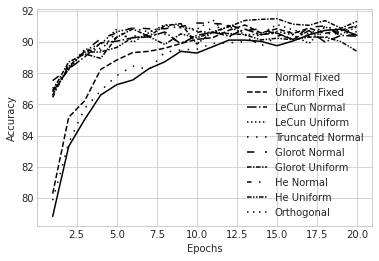

In [27]:
loss_values_gfixed = normal_dict['test_acc']
loss_values_ufixed = uniform_dict['test_acc']
loss_values_lecunnorm = lecunnorm_dict['test_acc']
loss_values_lecununiform = lecununif_dict['test_acc']
loss_values_trunc_norm = truncnorm_dict['test_acc']
loss_values_glorotnormal = glorotnorm_dict['test_acc']
loss_values_glorotunform = glorotunif_dict['test_acc']
loss_values_henormal = henorm_dict['test_acc']
loss_values_heuniform = heunif_dict['test_acc']
loss_values_orthog = orthog_dict['test_acc']
    
plt.plot(epochs, loss_values_gfixed, color='k', linestyle='-', label = 'Normal Fixed')
plt.plot(epochs, loss_values_ufixed, color='k', linestyle='--', label = 'Uniform Fixed')
plt.plot(epochs, loss_values_lecunnorm, color='k', linestyle='-.', label = 'LeCun Normal')
plt.plot(epochs, loss_values_lecununiform, color='k', linestyle=':', label = 'LeCun Uniform')
plt.plot(epochs, loss_values_trunc_norm, color='k', linestyle=(0, (1, 5)), label = 'Truncated Normal')
plt.plot(epochs, loss_values_glorotnormal, color='k', linestyle=(0, (5, 7)), label = 'Glorot Normal')
plt.plot(epochs, loss_values_glorotunform, color='k', linestyle=(0, (3, 1, 1, 1)), label = 'Glorot Uniform')
plt.plot(epochs, loss_values_henormal, color='k', linestyle=(0, (3, 5, 1, 5, 1, 5)), label = 'He Normal')
plt.plot(epochs, loss_values_heuniform, color='k', linestyle=(0, (3, 1, 1, 1, 1, 1)), label = 'He Uniform')
plt.plot(epochs, loss_values_orthog, color='k', linestyle=(0, (1, 3)), label = 'Orthogonal')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('TestMNISTWeightInitValid.png', dpi=300, bbox_inches='tight')